# HasoLift analysis 

The HasoHimgHasProcessor uses the Haso sdk to convert .himg files to .has slopes files and .has files to phase .tsv files. 

The analyze_image_file() method, rather than analyze_image() needs to be use so that the converted file types are saved in the proper location. The analyzer will save the raw phase files as well as processed phase files which applies a mask and subtracts user defined phase terms. By default, the processed file subtracts curvature, tilts, and astigmatism. The processed phase is the image that is returned at the end of the analysis.

In [1]:
# define paths to find configs and set up logging
from geecs_data_utils.scan_data import ScanPaths
from geecs_data_utils.config_roots import image_analysis_config

import logging

logging.getLogger("image_analysis").setLevel(logging.WARNING)
logging.getLogger("geecs_data_utils").setLevel(logging.WARNING)
logging.getLogger("image_analysis.algorithms.basic_line_stats").setLevel(logging.ERROR)


logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(name)s - %(levelname)s - %(message)s",
)


image_analysis_config.set_base_dir(ScanPaths.paths_config.image_analysis_configs_path)

WindowsPath('//131.243.169.248/HDNA2/software/control-all-loasis/HTU/Active Version/GEECS-Plugins-Configs/image_analysis_configs')

The HasoHimgHasProcessor is not a child of the config driven StandardAnalzyer class. Thus, it must be instantiated directly with kwargs as shown below. Critically, the wavekit_config_file_path must point to the proper config file for the camera that generated the data. 

In [2]:
from pathlib import Path
import yaml

from image_analysis.offline_analyzers.HASO_himg_has_processor import (
    HASOHimgHasProcessor,
)

dev_name = "U_HasoLift"

s = """
kwargs:
    wavekit_config_file_path: "Z:/software/control-all-loasis/HTU/Active Version/GEECS-Plugins/ImageAnalysis/image_analysis/third_party_sdks/wavekit_43/WFS_HASO4_LIFT_680_8244_gain_enabled.dat"
    mask_top: 200
    mask_bottom: 500
    mask_left: 10
    mask_right: 680
"""

kwargs = yaml.safe_load(s)["kwargs"]

haso_analzyer = HASOHimgHasProcessor(**kwargs)

file_path = Path(
    "Z:/data/Undulator/Y2026/03-Mar/26_0310/scans/Scan012/U_HasoLift/Scan012_U_HasoLift_001.himg"
)

res = haso_analzyer.analyze_image_file(file_path)

The HasoHimgHasProcessor does not have a native 'visualize' method, so we use a basic visualization here. Note, the mask and zernike subtraction is only applied to the returned 'processed_image' but raw versions (not masked, not zernike) subtracted are saved to the same directory with '_raw' tags. In the image below we can see the plasma imprint on a probe beam. Note, background subtraction is supported at this level, but it is recommended to use this analzyer primarily for file type conversion and then use e.g. BeamAnalzyer and it's supported background subtraction for further analysis.

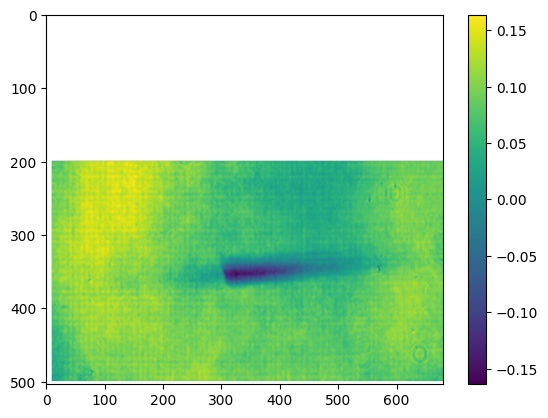

In [3]:
import matplotlib.pyplot as plt

plt.imshow(res.processed_image, aspect="auto")
plt.colorbar()
plt.show()

## Phase analysis 

Once Haso files have been converted to 'useable' formats, we can fall back to using the usual StandardAnalyzer style. In this case, we use DownrampPhaseAnalyzer which is a child of StandardAnalzyer allowing the use of the standard processing pipeline.

{'image_com_slope_x': -0.050858688846300334, 'image_com_slope_y': -2.689444391071016, 'image_peak_slope_x': -0.06495857913201154, 'image_peak_slope_y': -1.0872676160945576}


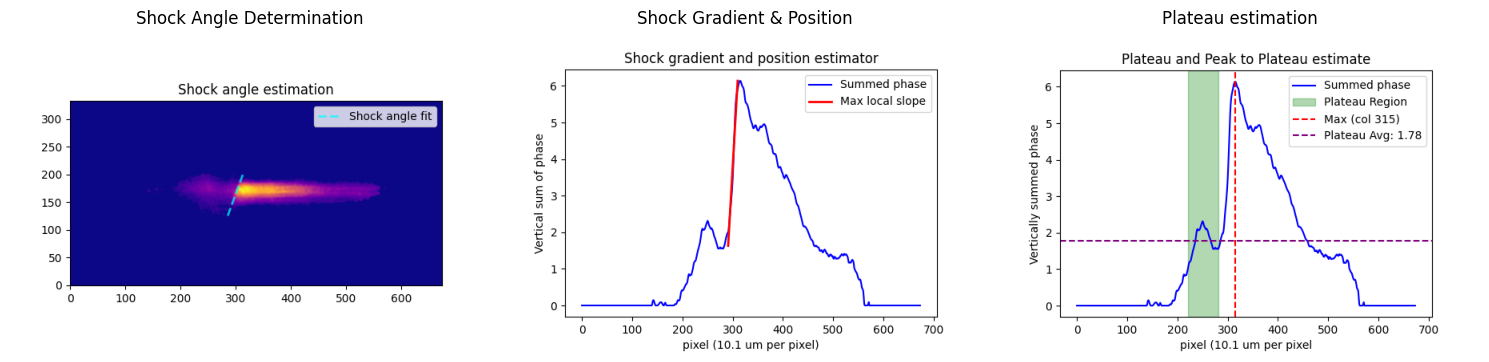

In [4]:
from pathlib import Path

from image_analysis.offline_analyzers.downramp_phase_analyzer import (
    DownrampPhaseAnalyzer,
)


dev_name = "U_PlasmaPhase"
file_path = Path(
    "Z:/data/Undulator/Y2026/03-Mar/26_0310/scans/Scan012/U_HasoLift/Scan012_U_HasoLift_150_postprocessed.tsv"
)

analyzer = DownrampPhaseAnalyzer(camera_config_name="U_PlasmaPhase")
res = analyzer.analyze_image_file(file_path)

In [5]:
res.scalars

{'Plasma downramp shock_angle': 0.3527175491019104,
 'Plasma downramp shock slope (phase/pixel)': 0.2372604079251326,
 'Plasma downramp shock location (pixel)': 301.0,
 'Plasma downramp plateau avg (phase)': 1.7832925752915336,
 'Plasma downramp peak to plateau (phase)': 4.357751000523257,
 'U_HasoLift_image_com_slope_x': -0.050858688846300334,
 'U_HasoLift_image_com_slope_y': -2.689444391071016,
 'U_HasoLift_image_peak_slope_x': -0.06495857913201154,
 'U_HasoLift_image_peak_slope_y': -1.0872676160945576}